In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score

In [40]:
df=pd.read_csv("house_price_ml_project.csv")
df.head()
               

,area_sqft,bedrooms,bathrooms,parking,age_years,location,price
0,956,1,1,1,7,Coimbatore,5060000
1,2733,1,2,0,0,Chennai,13880000
2,1452,5,4,1,22,Salem,8570000
3,1402,4,4,0,24,Coimbatore,8050000
4,1893,3,3,1,30,Madurai,9030000


In [5]:
df.isnull().sum()

area_sqft    0
bedrooms     0
bathrooms    0
parking      0
age_years    0
location     0
price        0
dtype: int64

In [6]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
495    False
496    False
497    False
498    False
499    False
Length: 500, dtype: bool

In [8]:
df.dtypes

area_sqft     int64
bedrooms      int64
bathrooms     int64
parking       int64
age_years     int64
location     object
price         int64
dtype: object

In [18]:
y=df["price"]
y.head(5)

0     5060000
1    13880000
2     8570000
3     8050000
4     9030000
Name: price, dtype: int64

In [17]:
x=df[["area_sqft","bedrooms","bathrooms","parking","age_years","location"]]
x.head()

,area_sqft,bedrooms,bathrooms,parking,age_years,location
0,956,1,1,1,7,Coimbatore
1,2733,1,2,0,0,Chennai
2,1452,5,4,1,22,Salem
3,1402,4,4,0,24,Coimbatore
4,1893,3,3,1,30,Madurai


In [57]:
x = df.drop("price", axis=1)
y = df["price"]

In [13]:
df.describe()

,area_sqft,bedrooms,bathrooms,parking,age_years,price
count,500.000000,500.000000,500.000000,500.00000,500.000000,5.000000e+02
mean,1766.986000,3.014000,2.812000,1.54200,14.768000,9.552340e+06
std,713.477387,1.424733,1.134562,1.11657,9.130658,3.264404e+06
min,504.000000,1.000000,1.000000,0.00000,0.000000,2.820000e+06
25%,1126.750000,2.000000,2.000000,1.00000,7.000000,6.730000e+06
50%,1771.000000,3.000000,3.000000,2.00000,15.000000,9.740000e+06
75%,2368.250000,4.000000,4.000000,3.00000,22.000000,1.230000e+07
max,3000.000000,5.000000,4.000000,3.00000,30.000000,1.631000e+07


In [16]:
pd.unique(df["location"])

array(['Coimbatore', 'Chennai', 'Salem', 'Madurai', 'Trichy'],
      dtype=object)

In [20]:
df["location"]=df["location"].replace({'Coimbatore':1, 'Chennai':2,"Salem":3 ,'Madurai':4,'Trichy':5})

C:\Users\gobinath\AppData\Local\Temp\ipykernel_18276\2651018154.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["location"]=df["location"].replace({'Coimbatore':1, 'Chennai':2,"Salem":3 ,'Madurai':4,'Trichy':5})


In [22]:
df.head(5)

,area_sqft,bedrooms,bathrooms,parking,age_years,location,price
0,956,1,1,1,7,1,5060000
1,2733,1,2,0,0,2,13880000
2,1452,5,4,1,22,3,8570000
3,1402,4,4,0,24,1,8050000
4,1893,3,3,1,30,4,9030000


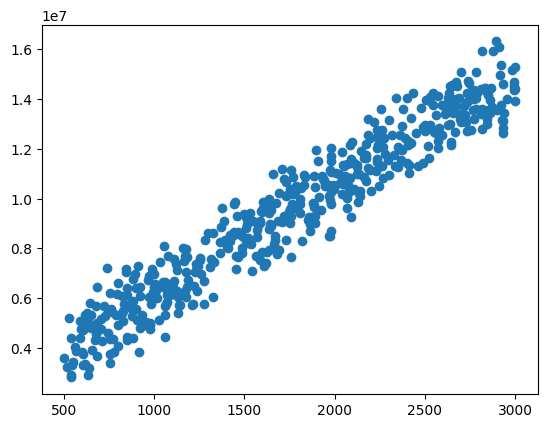

In [26]:
x=df["area_sqft"]
y=df["price"]
plt.scatter(x=x,y=y)

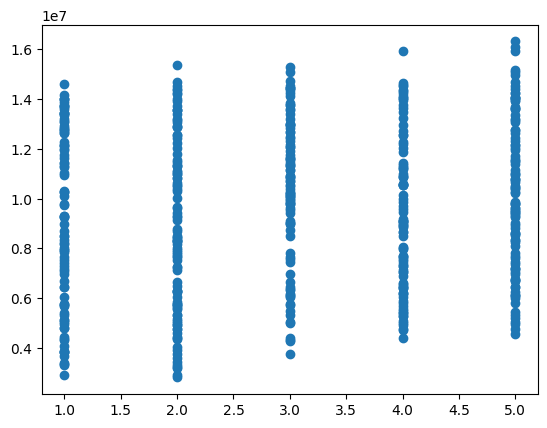

In [27]:
x1=df["bedrooms"]
plt.scatter(x=x1,y=y)

(array([[500.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
        [500.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
        [500.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
        [500.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
        [500.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
        [500.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
        [  0.,   5.,  35.,  79.,  61.,  72.,  85.,  70.,  80.,  13.]]),
 array([       0.,  1631000.,  3262000.,  4893000.,  6524000.,  8155000.,
         9786000., 11417000., 13048000., 14679000., 16310000.]),
 <a list of 7 BarContainer objects>)

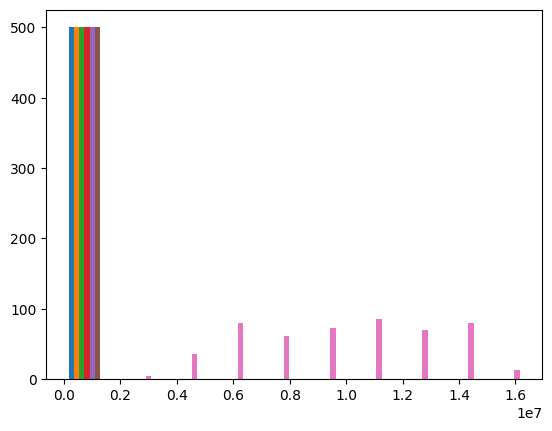

In [28]:
plt.hist(df)

In [37]:
co=df.corr()
co

,area_sqft,bedrooms,bathrooms,parking,age_years,location,price
area_sqft,1.000000,-0.080610,-0.064739,-0.015594,-0.034007,-0.002635,0.964757
bedrooms,-0.080610,1.000000,0.869464,-0.045091,0.089137,0.011159,0.112976
bathrooms,-0.064739,0.869464,1.000000,-0.044376,0.082253,0.017821,0.120148
parking,-0.015594,-0.045091,-0.044376,1.000000,0.018256,0.105958,0.021374
age_years,-0.034007,0.089137,0.082253,0.018256,1.000000,0.021814,-0.165181
location,-0.002635,0.011159,0.017821,0.105958,0.021814,1.000000,-0.037157
price,0.964757,0.112976,0.120148,0.021374,-0.165181,-0.037157,1.000000


<Axes: >

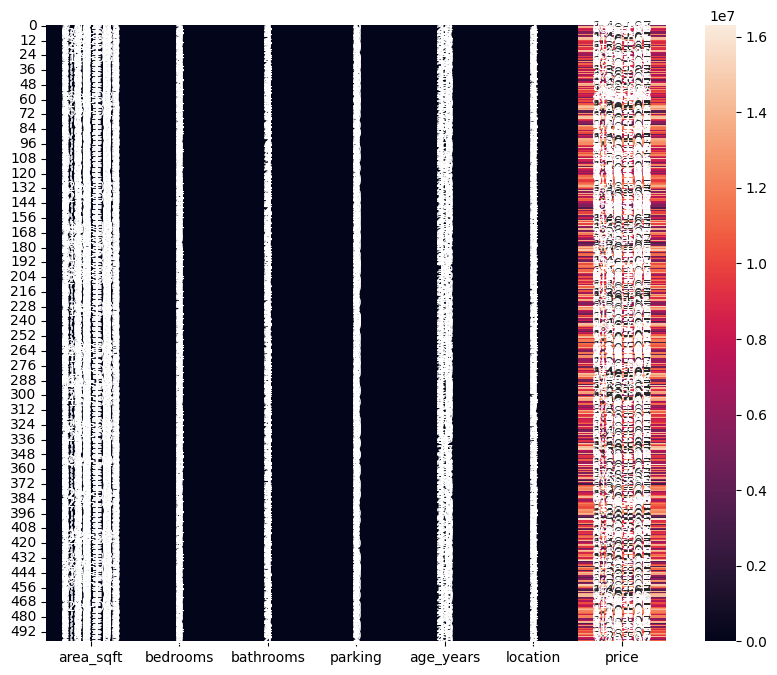

In [36]:
plt.figure(figsize=(10,8))

sns.heatmap(df,annot=True)


<Axes: >

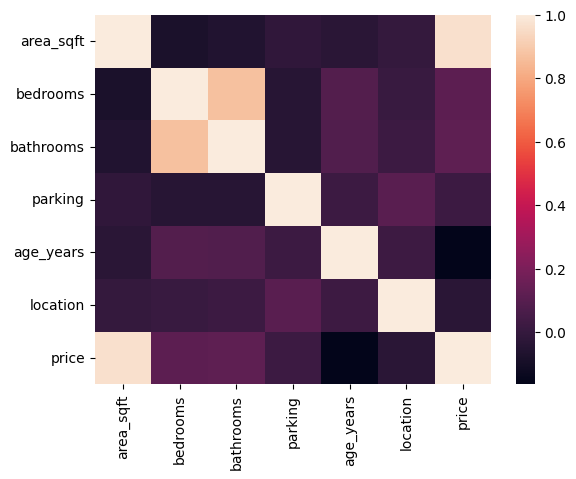

In [38]:
sns.heatmap(co)

In [41]:
df["location"]

0      Coimbatore
1         Chennai
2           Salem
3      Coimbatore
4         Madurai
          ...    
495       Madurai
496       Chennai
497        Trichy
498       Madurai
499        Trichy
Name: location, Length: 500, dtype: object

In [42]:
df = pd.get_dummies(df, columns=["location"], dtype=int)
df

,area_sqft,bedrooms,bathrooms,parking,age_years,price,location_Chennai,location_Coimbatore,location_Madurai,location_Salem,location_Trichy
0,956,1,1,1,7,5060000,0,1,0,0,0
1,2733,1,2,0,0,13880000,1,0,0,0,0
2,1452,5,4,1,22,8570000,0,0,0,1,0
3,1402,4,4,0,24,8050000,0,1,0,0,0
4,1893,3,3,1,30,9030000,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...
495,1806,5,4,0,28,9440000,0,0,1,0,0
496,2432,5,4,1,5,14250000,1,0,0,0,0
497,1487,3,2,1,18,7810000,0,0,0,0,1
498,1211,2,2,2,25,5730000,0,0,1,0,0


In [54]:
print(x.shape)
print(xtrain.shape)
print(x.head())

(500,)
(400,)
0     956
1    2733
2    1452
3    1402
4    1893
Name: area_sqft, dtype: int64


In [58]:
print(x.shape)
print(y.shape)

(500, 10)
(500,)


In [55]:
print(x.shape)
print(xtrain.shape)

(500,)
(400,)


In [67]:
model=LinearRegression()


In [68]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=42)

model=LinearRegression()

model.fit(xtrain,ytrain)

prediction=model.predict(xtest)

print(prediction[0])

test=df.iloc[0]

test

6469972.273907813


area_sqft                  956
bedrooms                     1
bathrooms                    1
parking                      1
age_years                    7
price                  5060000
location_Chennai             0
location_Coimbatore          1
location_Madurai             0
location_Salem               0
location_Trichy              0
Name: 0, dtype: int64

In [71]:
r2=root_mean_squared_error(ytest,prediction)
r2

174416.46093353082

In [73]:
r2_score(ytest,prediction)

0.9966250530764316